# CLEAR-HPV Demo (Raw WSI → CLAM → Concepts)

This demo uses **two SVS slides** (tracked via Git LFS in this repo) and runs the pipeline:

1) **Raw WSI (`.svs`) → CLAM tiling + feature extraction** (optional if features already exist)
2) **CLAM checkpoint** to compute **tile-level attention** and **h-space embeddings**
3) A trained **concept model** (e.g., `CLEAR-hpv_rawh` / `CLEAR-hpv_awh`) to assign each tile to a concept
4) Visualize a **spatial concept map (ROI overlay)** and a **concept-fraction bar plot**

The fraction plot **highlights clusters C5 and C7**.

## Requirements
- `openslide-python`, `Pillow`, `h5py`, `numpy`, `matplotlib`, `torch`, `joblib`
- CLAM code available locally (this notebook assumes you have a CLAM repo checkout)

> Note: If you already have `features/<SLIDE_ID>.h5`, you can skip the CLAM tiling/feature extraction cell.


## 0) Configuration

Edit paths below to match your environment.


In [1]:
from pathlib import Path

# --- Demo slides tracked by Git LFS in this repo ---
DEMO_SVS = {
    "TCGA-CN-6996": Path("HNSCC_slides/TCGA-CN-6996.svs"),
    "TCGA-BA-6869": Path("HNSCC_slides/TCGA-BA-6869-01Z-00-DX1.6e58648e-3309-47bb-b2c7-b71bcd9dc69b_001.svs"),
}

# Choose which demo slide to run
SLIDE_KEY = "TCGA-BA-6869"   # change to "TCGA-CN-6996" to use the other SVS
SVS_PATH  = DEMO_SVS[SLIDE_KEY]

# --- Output dirs for CLAM patching/features (can be temporary) ---
# These are used ONLY if you run the 'extract features' cell.
PATCH_ROOT = Path("./demo_patches")
FEAT_DIR   = Path("./demo_features/h5_files")
PATCH_ROOT.mkdir(parents=True, exist_ok=True)
FEAT_DIR.mkdir(parents=True, exist_ok=True)

# --- CLAM checkpoint used to compute attention + h-space ---
CLAM_WEIGHT = Path("results/HPV_CLAM_50_mb_s1/s_9_checkpoint.pt")

# --- Concept model to visualize (KMeans joblib) ---
# Point to your trained renamed folder output
model = Path("cluster_models/hpv_uni2_k10_rawh.joblib")

# --- Tile size for the demo overlay ---
TILE_SIZE_L0 = 256

# ROI selection: either 'relative' or 'manual'
ROI_MODE = "relative"
ROI_REL  = (0.50, 0.5, 0.7, 0.7)  # (cx_rel, cy_rel, w_rel, h_rel) in [0,1]
ROI_BOX_L0 = (10000, 12000, 16000, 18000)

# Overlay opacity
ALPHA = 120

# Batch size for projecting features through CLAM attention_net
BATCH = 16384

# dataset CSV for labels (adjust file + columns to match your repo)
DATA_CSV  = Path("dataset_csv/HNSCC.csv")   # change if needed
ID_COL    = "slide_id"                      # column containing IDs
LABEL_COL = "hpv_status"                    # e.g., "hpv_status" or "survival"
POS_NAME  = "HPV+"                          # label string treated as positive class

assert SVS_PATH.exists(), f"Missing demo SVS: {SVS_PATH} (did you run 'git lfs pull'?)"

## 1) (Optional) Extract CLAM features from raw WSI

If you already have an H5 file for this slide (features+coords), skip this cell.

This cell creates a tiny one-slide CSV and runs CLAM patching + feature extraction scripts.

You may need to adjust arguments to match your CLAM fork (script names/flags differ across versions).


In [2]:
import pandas as pd
import subprocess
from pathlib import Path

# Output H5 path expected by downstream steps
# We use the slide stem as slide_id for the demo
SLIDE_ID = SVS_PATH.stem
H5_PATH  = FEAT_DIR / f"{SLIDE_ID}.h5"

print("Slide ID:", SLIDE_ID)
print("SVS:", SVS_PATH)
print("H5 :", H5_PATH)

if H5_PATH.exists():
    print("[skip] Features already exist.")
else:
    # Create a minimal CSV required by many CLAM extract scripts
    csv_path = Path("./demo_slides.csv")
    # Typical CLAM expects a 'slide_id' column (without extension); adjust if your CLAM differs.
    pd.DataFrame({"slide_id": [SLIDE_ID]}).to_csv(csv_path, index=False)
    print("Wrote:", csv_path)

    # Example commands (you MUST adapt to your CLAM repo scripts/flags)
    patch_script = "create_patches_fp.py"
    feat_script  = "extract_features_fp.py"

    assert patch_script.exists(), f"Missing {patch_script} (update CLAM_ROOT or script name)"
    assert feat_script.exists(),  f"Missing {feat_script} (update CLAM_ROOT or script name)"

    cmd_patch = [
        "python", str(patch_script),
        "--source", str(SVS_PATH.parent),
        "--save_dir", str(PATCH_ROOT),
        "--patch_size", str(TILE_SIZE_L0),
        "--step_size", str(TILE_SIZE_L0),
        "--presets", "tcga.csv",
    ]
    print("Running patching:\n", " ".join(cmd_patch))
    subprocess.run(cmd_patch, check=True)

    cmd_feat = [
        "python", str(feat_script),
        "--data_slide_dir", str(SVS_PATH.parent),
        "--csv_path", str(csv_path),
        "--feat_dir", str(FEAT_DIR.parent),
        "--batch_size", "256",
        "--slide_ext", ".svs",
    ]
    print("Running feature extraction:\n", " ".join(cmd_feat))
    subprocess.run(cmd_feat, check=True)

    assert H5_PATH.exists(), "Feature extraction finished but H5 not found; check CLAM outputs and paths."


Slide ID: TCGA-BA-6869-01Z-00-DX1.6e58648e-3309-47bb-b2c7-b71bcd9dc69b_001
SVS: HNSCC_slides/TCGA-BA-6869-01Z-00-DX1.6e58648e-3309-47bb-b2c7-b71bcd9dc69b_001.svs
H5 : demo_features/h5_files/TCGA-BA-6869-01Z-00-DX1.6e58648e-3309-47bb-b2c7-b71bcd9dc69b_001.h5
[skip] Features already exist.


## 2) Load features + coords from H5

This demo expects `H5_PATH` to contain datasets:
- `features`: (N, D)
- `coords`: (N, 2) at level-0


In [3]:
import h5py, numpy as np

assert H5_PATH.exists(), f"Missing H5: {H5_PATH}"
with h5py.File(H5_PATH, "r") as f:
    feats = f["features"][:].astype(np.float32)
    coords = f["coords"][:].astype(np.int32)

print("features:", feats.shape, feats.dtype)
print("coords   :", coords.shape, coords.dtype)

label_str = "UNKNOWN"
y = None
if DATA_CSV.exists():
    df = pd.read_csv(DATA_CSV)
    assert ID_COL in df.columns, f"{DATA_CSV} must contain column '{ID_COL}'"
    assert LABEL_COL in df.columns, f"{DATA_CSV} must contain column '{LABEL_COL}'"
    df = df.set_index(ID_COL)

    # try exact match; otherwise try common TCGA shortening (first 12 chars) fallback
    if SLIDE_ID in df.index:
        label_str = str(df.at[SLIDE_ID, LABEL_COL])
        print(f"Found label for {SLIDE_ID} in {DATA_CSV}")

    y = 1 if label_str == POS_NAME else 0
print("SLIDE_ID:", SLIDE_ID)
print("label  :", label_str, "y:", y)

features: (50085, 1536) float32
coords   : (50085, 2) int32
Found label for TCGA-BA-6869-01Z-00-DX1.6e58648e-3309-47bb-b2c7-b71bcd9dc69b_001 in dataset_csv/HNSCC.csv
SLIDE_ID: TCGA-BA-6869-01Z-00-DX1.6e58648e-3309-47bb-b2c7-b71bcd9dc69b_001
label  : HPV+ y: 1


## 3) CLAM projection: h-space + attention


In [4]:
import torch, joblib, gc
from models.model_clam import CLAM_MB

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

@torch.inference_mode()
def load_clam(weight_path: Path, device: str, embed_dim: int):
    m = CLAM_MB(gate=True, size_arg="small", n_classes=2, embed_dim=embed_dim)
    sd = torch.load(weight_path, map_location=device)
    m.load_state_dict(sd, strict=False)
    return m.to(device).eval()

@torch.inference_mode()
def project_h_and_attention(X: np.ndarray, clam: CLAM_MB, device: str, batch: int):
    H_list, A_list = [], []
    for off in range(0, X.shape[0], batch):
        x = torch.from_numpy(X[off:off+batch]).to(device)
        A_raw, h = clam.attention_net(x)
        a = torch.softmax(A_raw[:, 0], dim=0)
        a = a * (a.numel() / a.sum())
        H_list.append(h.cpu().numpy().astype(np.float32))
        A_list.append(a.cpu().numpy().astype(np.float32))
        del x, A_raw, h, a
        gc.collect()
    return np.concatenate(H_list, 0), np.concatenate(A_list, 0)

clam = load_clam(CLAM_WEIGHT, DEVICE, embed_dim=feats.shape[1])
km = joblib.load(model)

H, attn = project_h_and_attention(feats, clam, DEVICE, batch=BATCH)
print("h:", H.shape, "attn:", attn.shape)
print("KMeans k:", getattr(km, "n_clusters", None))


DEVICE: cuda
h: (50085, 512) attn: (50085,)
KMeans k: 10


## 4) Select ROI and render concept overlay


In [5]:
# Legend for concepts (colors + C0..CK-1), with C5/C7 emphasized

import numpy as np
from matplotlib.patches import Patch
import openslide
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def base_palette_colors(K: int):
    base_hex = [
        "#E41A1C","#377EB8","#031B2E","#984EA3","#FF7F00",
        "#FFD92F","#F781BF","#66C2A5","#A65628","#999999",
    ]
    base = np.array([mcolors.to_rgb(h) for h in base_hex], dtype=float)
    reps = int(np.ceil(K / len(base_hex)))
    return (np.tile(base, (reps, 1))[:K] * 255).astype(np.uint8)

def concept_legend_ax(colors_uint8, concept_names=None, title="Concepts", highlight={5, 7},
                     ncol=5, fontsize=11):
    """
    colors_uint8: (K,3) uint8 RGB (same palette used in overlays)
    concept_names: optional list of K strings; default "C0..C(K-1)"
    """
    K = int(colors_uint8.shape[0])
    if concept_names is None:
        concept_names = [f"C{i}" for i in range(K)]
    assert len(concept_names) == K

    handles = []
    for i in range(K):
        rgb = tuple((colors_uint8[i].astype(float) / 255.0).tolist())
        name = concept_names[i]
        if i == 5:
            name = f"{name} (basaloid squamous epithelium)"
        if i == 7:
            name = f"{name} (keratinizing squamous epithelium)"
        if i == 2:
            name = f"{name} (inflammatory cells)"
        if i == 9:
            name = f"{name} (fibrous stroma)"
        if i == 4:
            name = f"{name} (connective stroma)"
        handles.append(Patch(facecolor=rgb, edgecolor="black", label=name))

    fig, ax = plt.subplots(figsize=(max(6, 1.2 * ncol), 1.6 + 0.35 * (K // ncol + 1)), dpi=200)
    ax.axis("off")
    leg = ax.legend(
        handles=handles,
        title=title,
        loc="center",
        ncol=ncol,
        frameon=True,
        fontsize=fontsize,
        title_fontsize=fontsize + 1,
        handlelength=1.2,
        handleheight=1.2,
        columnspacing=1.2,
        labelspacing=0.8,
    )

    # emphasize highlighted entries
    for txt in leg.get_texts():
        if "(highlight)" in txt.get_text():
            txt.set_fontweight("bold")

    plt.show()

colors = base_palette_colors(km.n_clusters)

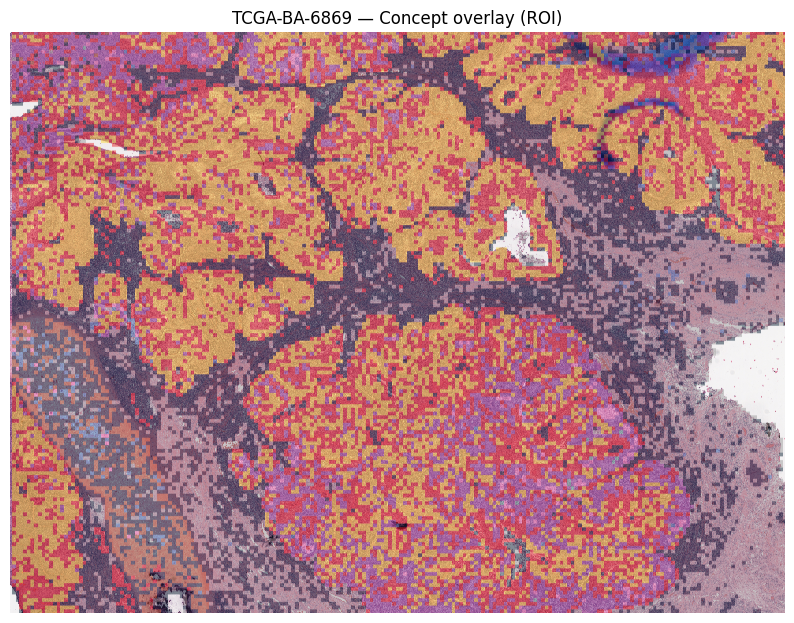

In [6]:
def rel_box_to_abs_level0(rel_box, slide_wh_l0, align=TILE_SIZE_L0):
    cxr, cyr, wr, hr = rel_box
    W0, H0 = slide_wh_l0
    cx = float(np.clip(cxr, 0, 1)) * W0
    cy = float(np.clip(cyr, 0, 1)) * H0
    w = max(align, int(round(float(np.clip(wr, 0, 1)) * W0)))
    h = max(align, int(round(float(np.clip(hr, 0, 1)) * H0)))
    x0 = int(round(cx - w/2)); y0 = int(round(cy - h/2))
    x1 = x0 + w; y1 = y0 + h
    x0 = max(0, min(x0, W0-1)); y0 = max(0, min(y0, H0-1))
    x1 = max(1, min(x1, W0));   y1 = max(1, min(y1, H0))
    x0 = (x0 // align) * align
    y0 = (y0 // align) * align
    x1 = min(W0, x0 + ((w // align) * align))
    y1 = min(H0, y0 + ((h // align) * align))
    if x1 <= x0: x1 = min(W0, x0 + align)
    if y1 <= y0: y1 = min(H0, y0 + align)
    return (x0, y0, x1, y1)

def filter_by_roi(coords_l0: np.ndarray, roi_box_l0):
    x0,y0,x1,y1 = roi_box_l0
    return ((coords_l0[:,0] >= x0) & (coords_l0[:,0] < x1) &
            (coords_l0[:,1] >= y0) & (coords_l0[:,1] < y1))

def render_roi_overlay_level0(svs_path: Path, roi_box_l0, coords_roi_l0, labels_roi, colors_uint8,
                              tile_size_l0=TILE_SIZE_L0, alpha=120):
    x0, y0, x1, y1 = roi_box_l0
    W, H = x1 - x0, y1 - y0
    slide = openslide.OpenSlide(str(svs_path))
    region = slide.read_region((x0, y0), 0, (W, H)).convert("RGBA")
    slide.close()
    bg = Image.new("RGBA", region.size, (255,255,255,255))
    roi_rgb = Image.alpha_composite(bg, region).convert("RGB")
    overlay = Image.new("RGBA", (W, H), (0,0,0,0))
    draw = ImageDraw.Draw(overlay, "RGBA")
    w = tile_size_l0
    for (tx, ty), lab in zip(coords_roi_l0, labels_roi):
        x = int(tx - x0); y = int(ty - y0)
        r,g,b = map(int, colors_uint8[int(lab)])
        draw.rectangle([x, y, x+w, y+w], fill=(r,g,b,alpha), outline=None)
    roi_overlay = Image.alpha_composite(roi_rgb.convert("RGBA"), overlay).convert("RGB")
    return roi_rgb, roi_overlay

osl = openslide.OpenSlide(str(SVS_PATH))
W0, H0 = osl.dimensions
osl.close()

roi_box = rel_box_to_abs_level0(ROI_REL, (W0, H0), align=TILE_SIZE_L0) if ROI_MODE == "relative" else ROI_BOX_L0
mask_roi = filter_by_roi(coords, roi_box)
assert mask_roi.any(), "No tiles in ROI; adjust ROI parameters."

labels_roi = km.predict(H[mask_roi]).astype(np.int32)
coords_roi = coords[mask_roi]


roi_orig, roi_overlay = render_roi_overlay_level0(SVS_PATH, roi_box, coords_roi, labels_roi, colors, tile_size_l0=TILE_SIZE_L0, alpha=ALPHA)

plt.figure(figsize=(10, 10))
plt.imshow(roi_overlay)
plt.axis('off')
plt.title(f"{SLIDE_KEY} — Concept overlay (ROI)")
plt.show()


## 5) Concept-fraction plot from the same ROI (highlight C5 and C7)

Fractions are computed **from the ROI assignments** with attention weights. 


This slide has the following concept fractions (ATTENTION-weighted):
ROI fracs: [0.005066, 5e-06, 4.2e-05, 0.031219, 0.0, 0.962185, 4.2e-05, 0.001344, 8.7e-05, 1e-05]
The label for this slide is: HPV+


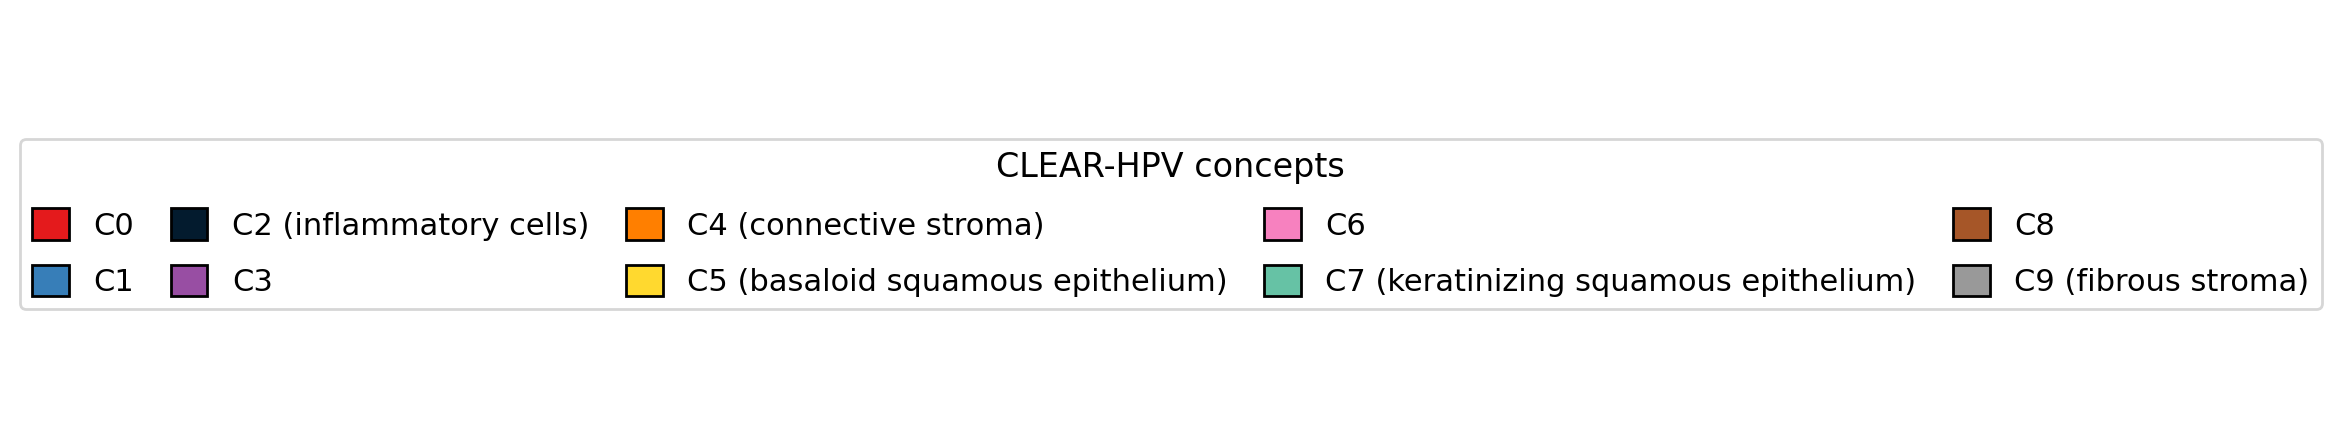

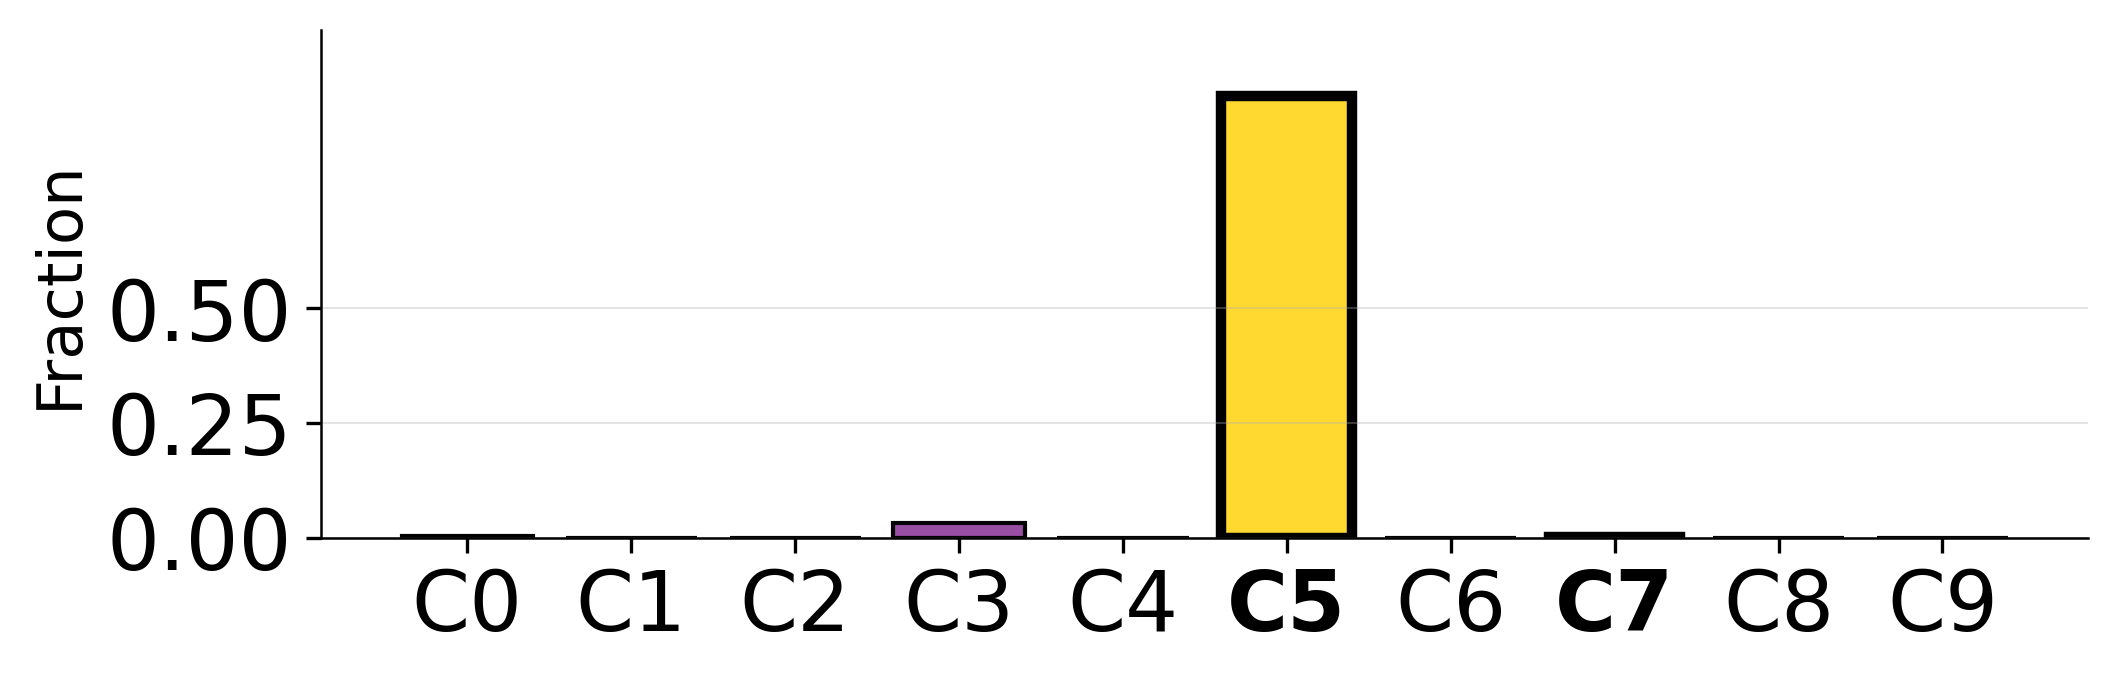

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

Kc = int(getattr(km, "n_clusters", labels_roi.max() + 1))
counts = np.bincount(labels_roi, minlength=Kc).astype(float)

# Unweighted fractions 
fracs_uw = counts / max(1.0, counts.sum())

# ATTENTION-weighted fractions 
w = attn[mask_roi].astype(float)
fracs = np.bincount(labels_roi, weights=w, minlength=Kc)
fracs = fracs / max(1e-12, fracs.sum())

def base_palette_colors_rgb(K: int):
    base_hex = [
        "#E41A1C","#377EB8","#031B2E","#984EA3","#FF7F00",
        "#FFD92F","#F781BF","#66C2A5","#A65628","#999999",
    ]
    base = np.array([mcolors.to_rgb(h) for h in base_hex], dtype=float)
    reps = int(np.ceil(K / len(base_hex)))
    return np.tile(base, (reps, 1))[:K]

def plot_cluster_fractions(fracs, orientation="v", sort=False, show_values=False, highlight={5,7}):
    fracs = np.asarray(fracs, float)
    K = len(fracs)
    colors = base_palette_colors_rgb(K)

    labels = [f"C{i}" for i in range(K)]
    if sort:
        order = np.argsort(fracs)[::-1]
        fracs = fracs[order]
        colors = colors[order]
        labels = [labels[i] for i in order]
        inv = {old:new for new, old in enumerate(order)}
        highlight = {inv[i] for i in highlight if i in inv}
    else:
        highlight = set(highlight)

    fig, ax = plt.subplots(figsize=(7, 2.2), dpi=300)
    bars = ax.bar(np.arange(K), fracs, color=colors, edgecolor="black", width=0.8)
    ax.set_xticks(np.arange(K))
    ax.set_xticklabels(labels, fontsize=20)
    ax.set_ylabel("Fraction", fontsize=15)
    ax.set_ylim(0, max(0.01, fracs.max()) * 1.15)
    ax.set_yticks([0, 0.25, 0.5])
    ax.tick_params(axis="y", labelsize=20)
    for i, tick in enumerate(ax.get_xticklabels()):
        if i in highlight:
            tick.set_fontweight("bold")
    ax.grid(axis="y", linewidth=0.4, alpha=0.4)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_linewidth(0.6)
    ax.spines["bottom"].set_linewidth(0.6)

    for i in highlight:
        if 0 <= i < len(bars):
            bars[i].set_linewidth(2.5)

    fig.tight_layout(pad=0.5)
    plt.show()

print("This slide has the following concept fractions (ATTENTION-weighted):")
print("ROI fracs:", np.round(fracs, 6).tolist())
print("The label for this slide is:", label_str)
concept_legend_ax(colors, title="CLEAR-HPV concepts", highlight={5, 7}, ncol=5)
plot_cluster_fractions(fracs, highlight={5,7})
